# 33. Rank Revealing QR and Total Least Squares

**Part 5: Orthogonality, QR and Least Squares**

## Learning objectives

By the end of this lesson you will be able to:

1. Say why an ordinary QR factorization **cannot** report the numerical rank, and what has to
   change so that it can.
2. Implement **column pivoted QR**, $AP = QR$, and explain why the column norms are downdated
   rather than recomputed.
3. Read a **rank gap** off the diagonal of $R$, and recognise when there is no gap to read.
4. Construct **Kahan's matrix** and use it to show that rank revealing QR is a heuristic with a
   known counterexample, not a theorem.
5. Use the same pivots for **subset selection**, and measure how far the greedy choice is from
   the best one.
6. State the **total least squares** problem, solve it with the smallest singular vector of
   $[A \mid \mathbf{b}]$, and say when it has no solution.
7. Predict the **attenuation bias** in ordinary least squares when $A$ is measured with error,
   and confirm that more data does not remove it.
8. Explain why total least squares is **worse conditioned** than the problem it corrects.

## Prerequisites

Lesson 31 (Householder QR, which this builds on directly). Lesson 32 (the SVD as a tool, the
numerical rank, and the `rcond` threshold this lesson is a response to). Lesson 29 (the normal
equations). The SVD itself is built in lesson 41; here it is used.

---

## 1. What an ordinary QR cannot tell you

Lesson 32 ended badly. The SVD's `rcond` threshold decided the numerical rank, that decision
changed the answer by a factor of 2600, and QR had nothing at all to say about it. Worse, QR
did not even fail loudly: on a rank deficient matrix it produced a factorization with a tiny
$r_{nn}$, divided by it, and returned a number.

**The reason is that ordinary QR takes the columns in the order they arrive.** Column $j$ is
orthogonalized against columns $1$ through $j-1$ whatever those happen to be, so $r_{jj}$ is
small whenever column $j$ is nearly explained by its **predecessors**, and large otherwise.
That is a fact about the ordering as much as about the matrix.

**The consequence is that the diagonal of a plain $R$ is not sorted**, and every way of reading
a rank off it assumes that it is. Put a duplicated column early and see what happens.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import rrqr, qr as qrmod, leastsquares as ls

# Rank 4 in 6 columns. The duplicate sits at position 1, so it is the SECOND column that is
# redundant, not the last two. The matrix does not care; plain QR does.
m, n, true_rank = 40, 6, 4
basis = rng.standard_normal((m, true_rank))
A_dup = np.column_stack([basis[:, 0], basis[:, 0], basis[:, 1], basis[:, 2],
                         basis[:, 3], basis[:, 1] + basis[:, 2]])

_, R_plain = qrmod.householder_qr(A_dup)
d_plain = np.abs(np.diag(R_plain))
d_piv = rrqr.qr_column_pivoted(A_dup).diagonal

print(f"a {m} by {n} matrix of rank {true_rank}\n")
print("plain QR   :", np.array2string(d_plain, precision=3))
print("pivoted QR :", np.array2string(d_piv, precision=3))

# The rule everyone uses: count entries until the diagonal falls off a cliff.
def count_until_the_cliff(d):
    """Walk down the diagonal and stop at the first big drop. This is the rule people apply,
    and it is only valid when the diagonal is sorted."""
    for k in range(d.size - 1):
        if d[k + 1] < 1e-8 * d[0]:
            return k + 1
    return int(d.size)

print(f"\nreading the rank off plain QR   : {count_until_the_cliff(d_plain)}")
print(f"reading the rank off pivoted QR : {count_until_the_cliff(d_piv)}")
print(f"the truth                       : {true_rank}")
assert count_until_the_cliff(d_piv) == true_rank
assert count_until_the_cliff(d_plain) != true_rank

a 40 by 6 matrix of rank 4

plain QR   : [5.138e+00 1.155e-15 4.733e+00 5.905e+00 5.206e+00 1.475e-15]
pivoted QR : [7.819e+00 5.547e+00 4.910e+00 3.709e+00 1.113e-15 1.334e-17]

reading the rank off plain QR   : 1
reading the rank off pivoted QR : 4
the truth                       : 4


**Plain QR puts a roundoff-sized entry at position 2 and then goes back to full-sized
entries.** The cliff is in the middle, so the rule stops at 1 and reports rank 1 for a matrix of
rank 4. The information is all still there, in the sense that four entries are large, but their
**positions** encode the order you happened to supply, and no rule that reads left to right can
recover from that.

**Pivoted QR sorts the diagonal**, so the cliff is where the rank is, and the same rule works.

**It also matters when nothing is exactly dependent**, though here the effect is mild. The
smallest diagonal entry of any $R$ is an **upper bound** on $\sigma_{\min}$, so both versions
overstate how far the matrix is from singular, and the question is by how much.

In [3]:
print(f"{'kappa':>9}{'min |r_kk|, plain':>20}{'min |r_kk|, pivoted':>22}"
      f"{'sigma_min':>13}{'plain overstates by':>21}")
for expo in (4, 8, 12):
    M = ls.graded_design(50, 8, 10.0 ** expo, np.random.default_rng(11))
    M = M[:, rng.permutation(M.shape[1])]           # an arbitrary column order
    small_plain = np.abs(np.diag(qrmod.householder_qr(M)[1])).min()
    small_piv = rrqr.qr_column_pivoted(M).diagonal[-1]
    s_min = np.linalg.svd(M, compute_uv=False)[-1]
    print(f"{10.0 ** expo:>9.0e}{small_plain:>20.3e}{small_piv:>22.3e}"
          f"{s_min:>13.3e}{small_plain / s_min:>21.2f}")

    kappa   min |r_kk|, plain   min |r_kk|, pivoted    sigma_min  plain overstates by
    1e+04           3.276e-04             1.940e-04    1.000e-04                 3.28
    1e+08           2.326e-08             2.065e-08    1.000e-08                 2.33
    1e+12           3.472e-12             2.327e-12    1.000e-12                 3.47


**Both overstate by a factor of 2 to 3.5 here, and pivoting is only slightly the better of
the two.** So this is not the argument for pivoting: on a graded matrix with no exact
dependence, the plain smallest diagonal entry is already a usable estimate of $\sigma_{\min}$
whatever order the columns arrive in.

**The argument for pivoting is the previous cell**: the diagonal comes out **sorted**, so the
rank is where the cliff is, and the cliff is somewhere you can find. Section 4 shows the price
of that convenience.

**So the fix is to choose the order.**

---

## 2. Column pivoting

At step $k$, instead of taking column $k$, take the column whose part **not yet explained** by
the previous ones is longest, and swap it into position $k$. Then eliminate it as usual.

$$A P = QR, \qquad |r_{11}| \ge |r_{22}| \ge \cdots \ge |r_{nn}|,$$

with $P$ a permutation matrix. The diagonal is non-increasing **by construction**, not by luck,
because at each step you took the largest available.

**The quantity being maximised is a column norm of the trailing block.** Recomputing all of
them at each step costs $O(m(n-k))$, which would add $O(mn^2)$ to the factorization and roughly
double its cost. So they are **downdated** instead:

$$c_j^{\text{new}} = c_j\sqrt{1 - (r_{kj}/c_j)^2},$$

which is $O(n)$ per step. That is Pythagoras: removing a perpendicular component of length
$r_{kj}$ from a vector of length $c_j$.

**And the downdate is exactly the cancellation of lesson 05.** When $r_{kj}$ is close to $c_j$
the bracket is a difference of nearly equal numbers, and the result loses digits precisely when
the norm collapses, which is the case this whole algorithm exists to detect. LINPACK's
compromise, which `qr_column_pivoted` uses, is to recompute a column's norm from the trailing
block whenever the downdated value has fallen below a fixed fraction of where it started. That
costs a recomputation only where it matters.

In [4]:
piv3 = rrqr.qr_column_pivoted(A_dup)

print(f"pivoted QR of the same rank {true_rank} matrix\n")
print("column order chosen :", piv3.piv)
print("R diagonal          :", np.array2string(piv3.diagonal, precision=3))
print(f"\nnumerical rank reported: {piv3.rank}   (the truth is {true_rank})")

# the factorization identity, which pivoting does not damage
fact = np.linalg.norm(A_dup[:, piv3.piv] - piv3.Q @ piv3.R) / np.linalg.norm(A_dup)
orth = np.linalg.norm(piv3.Q.T @ piv3.Q - np.eye(piv3.Q.shape[1]))
print(f"\n||A[:, piv] - QR|| / ||A|| = {fact:.2e}")
print(f"||Q^T Q - I||              = {orth:.2e}")
assert fact < 1e-13 and orth < 1e-13
assert piv3.rank == true_rank

pivoted QR of the same rank 4 matrix

column order chosen : [5 4 1 2 3 0]
R diagonal          : [7.819e+00 5.547e+00 4.910e+00 3.709e+00 1.113e-15 1.334e-17]

numerical rank reported: 4   (the truth is 4)

||A[:, piv] - QR|| / ||A|| = 4.67e-16
||Q^T Q - I||              = 1.16e-15


**Four entries of order 1 and then a cliff.** The drop from $r_{44}$ to $r_{55}$ is the rank,
and it is visible without knowing the answer in advance.

**Pivoting costs almost nothing.** The extra work is the pivot search and the downdate, both
$O(n)$ per step against the elimination's $O(mn)$, so the overhead is $O(n^2)$ against
$O(mn^2)$: a fraction $1/m$.

In [5]:
import time

print(f"{'shape':>12}{'plain QR':>12}{'pivoted':>11}{'overhead':>11}{'predicted 1/m':>15}")
for m_t, n_t in ((400, 100), (800, 150), (1500, 200)):
    M = rng.standard_normal((m_t, n_t))
    t0 = time.perf_counter(); qrmod.householder_qr(M); t_plain = time.perf_counter() - t0
    t0 = time.perf_counter(); rrqr.qr_column_pivoted(M); t_piv = time.perf_counter() - t0
    print(f"{f'{m_t}x{n_t}':>12}{t_plain:>11.3f}s{t_piv:>10.3f}s"
          f"{t_piv / t_plain - 1:>10.1%}{1.0 / m_t:>15.2%}")

       shape    plain QR    pivoted   overhead  predicted 1/m
     400x100      0.012s     0.098s    699.8%          0.25%


     800x150      0.098s     0.646s    559.7%          0.12%


    1500x200      0.425s     3.769s    786.5%          0.07%


**The measured overhead is 530 to 800 percent, against a prediction of a fraction of one
percent**, and the reason is not the flops. The pivot search and the norm downdate are short
Python loops running once per column, while the elimination is a single numpy call on a large
block. This is the same effect lesson 31 measured for Givens rotations, and lesson 30 measured
for blocking: **an $O(n^2)$ interpreted loop can cost more than $O(mn^2)$ of compiled work.**

**The flop count is still the right guide for a real implementation.** LAPACK's `dgeqp3` does
the same arithmetic in compiled code and blocks the trailing update, and its overhead over
`dgeqrf` really is the few percent the count predicts. What the table measures is this
implementation, and it is reported as such rather than presented as a property of the
algorithm.

---

## 3. Reading the rank off the diagonal

The rule is: find the largest ratio between consecutive diagonal entries, and call the number
of entries above it the rank.

In [6]:
print(f"{'shape':>10}{'true rank':>11}{'QR rank':>9}{'SVD rank':>10}"
      f"{'gap at':>8}{'gap size':>12}   verdict")
for m_r, n_r, r_r in ((40, 10, 4), (60, 12, 7), (100, 15, 9), (20, 20, 1), (30, 6, 6)):
    M = rng.standard_normal((m_r, r_r)) @ rng.standard_normal((r_r, n_r))
    piv = rrqr.qr_column_pivoted(M)
    gap = rrqr.rank_gap(piv.diagonal)
    deficient = r_r < min(m_r, n_r)
    real = gap["ratio"] > 1e6
    print(f"{f'{m_r}x{n_r}':>10}{r_r:>11}{piv.rank:>9}"
          f"{rrqr.numerical_rank(M):>10}{gap['index']:>8}{gap['ratio']:>12.2e}"
          f"   {'a real gap' if real else 'NO real gap'}")
    assert piv.rank == r_r, f"rank {piv.rank} against a true {r_r}"
    # The gap only means something when there IS one. On a full rank matrix the largest ratio
    # between neighbouring diagonal entries is just the largest of several ordinary ratios, and
    # reading a rank off it would be reading noise.
    if deficient:
        assert real and gap["index"] == r_r, f"gap at {gap['index']}, expected {r_r}"
    else:
        assert not real, f"a full rank matrix should show no gap, found {gap['ratio']:.2e}"

     shape  true rank  QR rank  SVD rank  gap at    gap size   verdict
     40x10          4        4         4       4    3.19e+15   a real gap
     60x12          7        7         7       7    2.59e+15   a real gap
    100x15          9        9         9       9    4.18e+14   a real gap
     20x20          1        1         1       1    1.53e+16   a real gap
      30x6          6        6         6       5    2.06e+00   NO real gap


**Read the last row before the others.** The $30\times6$ matrix has rank 6 out of 6, so it is
**full rank and there is no gap to find**. The gap finder still returns its largest ratio,
because that is what it was asked for, and that ratio is a small number of order 1. Taking its
index as a rank would be reading noise.

**The four deficient cases all agree, and their gaps are enormous**, of order $10^{15}$, because
those matrices are exactly rank deficient and the entries below the gap are pure roundoff.

**So the rank estimate and the gap are two different outputs.** `piv.rank` compares against a
threshold and is always defined; the gap is a claim that the threshold was in an obvious place,
and it is only available when the matrix has one. The next cell makes the distinction concrete.

**The honest question is what happens when there is no gap.** Lesson 32 exercise 4.3 already
established that a geometrically spaced spectrum has no rank to find. The gap finder should
report that rather than inventing an index.

In [7]:
smooth = np.geomspace(1.0, 1e-10, 12)
gap_smooth = rrqr.rank_gap(smooth)
common = smooth[0] / smooth[1]
print("a spectrum with no gap:", np.array2string(smooth[:5], precision=2), "...")
print(f"  largest ratio found : {gap_smooth['ratio']:.4f} at index {gap_smooth['index']}")
print(f"  the common ratio    : {common:.4f}")
print("  they are the same number, so the 'gap' is just the spacing and means nothing")
assert abs(gap_smooth["ratio"] - common) < 1e-9 * common

sharp = np.array([1.0, 0.7, 0.4, 1e-12, 3e-13, 1e-13])
gap_sharp = rrqr.rank_gap(sharp)
print(f"\na spectrum with a gap : largest ratio {gap_sharp['ratio']:.2e} at index "
      f"{gap_sharp['index']}")
print("  that ratio is 11 orders of magnitude above the surrounding ones, so it is real")

a spectrum with no gap: [1.00e+00 1.23e-01 1.52e-02 1.87e-03 2.31e-04] ...
  largest ratio found : 8.1113 at index 11
  the common ratio    : 8.1113
  they are the same number, so the 'gap' is just the spacing and means nothing

a spectrum with a gap : largest ratio 4.00e+11 at index 3
  that ratio is 11 orders of magnitude above the surrounding ones, so it is real


**A rank gap is a statement about a ratio being an outlier, not about it being large.** In the
smooth case the largest ratio equals the typical ratio, and the right conclusion is that there
is no rank.

---

## 4. Kahan's matrix, where the whole idea fails

Rank revealing QR is a **heuristic**. It works on the matrices people usually meet, and there
is a matrix on which it fails completely, which has been known since Kahan pointed it out.

$$K = \operatorname{diag}(1, s, s^2, \dots, s^{n-1})
\begin{pmatrix} 1 & -c & -c & \cdots \\ & 1 & -c & \cdots \\ & & 1 & \cdots \\
& & & \ddots \end{pmatrix},
\qquad c = \cos\theta,\ s = \sin\theta.$$

**Every column has the same norm.** So at step 1 the pivot search finds a tie, and by the
convention of taking the first maximum it keeps column 1. The same happens at every subsequent
step. **Pivoting never swaps anything**, and the algorithm returns the matrix it was given.

In [8]:
print(f"{'n':>5}{'swaps':>7}{'min |r_kk| / |r_11|':>22}{'sigma_n / sigma_1':>20}"
      f"{'understated by':>17}")
for n_k in (10, 20, 30, 40, 50):
    K = rrqr.kahan_matrix(n_k)
    out = rrqr.qr_column_pivoted(K)
    sv = np.linalg.svd(K, compute_uv=False)
    d = out.diagonal
    swaps = int(np.sum(out.piv != np.arange(n_k)))
    qr_ratio = d[-1] / d[0]
    sv_ratio = sv[-1] / sv[0]
    print(f"{n_k:>5}{swaps:>7}{qr_ratio:>22.3e}{sv_ratio:>20.3e}"
          f"{qr_ratio / sv_ratio:>17.2e}")
    assert swaps == 0, "pivoting should find nothing to swap on a Kahan matrix"

    n  swaps   min |r_kk| / |r_11|   sigma_n / sigma_1   understated by
   10      0             2.059e-04           3.294e-07         6.25e+02
   20      0             1.652e-08           2.688e-14         6.15e+05
   30      0             1.325e-12           2.556e-21         5.18e+08
   40      0             1.062e-16           2.586e-28         4.11e+11
   50      0             8.519e-21           2.705e-35         3.15e+14


**Zero swaps at every size**, and the two ratios diverge without limit. At $n = 50$ pivoted QR
reports a matrix whose smallest diagonal entry is $10^{-11}$ of its largest, comfortably full
rank, while the true smallest singular value is $10^{-25}$ of the largest.

**The consequence for the rank verdict**, which is what actually gets used:

In [9]:
print(f"{'n':>5}{'QR rank':>9}{'SVD rank':>10}{'kappa by QR':>15}{'kappa true':>14}"
      f"{'factor':>11}")
for n_k in (12, 20, 24, 28, 32, 40):
    K = rrqr.kahan_matrix(n_k)
    d = rrqr.qr_column_pivoted(K).diagonal
    sv = np.linalg.svd(K, compute_uv=False)
    print(f"{n_k:>5}{rrqr.numerical_rank(K, method='qr'):>9}"
          f"{rrqr.numerical_rank(K, method='svd'):>10}"
          f"{d[0] / d[-1]:>15.2e}{sv[0] / sv[-1]:>14.2e}"
          f"{(sv[0] / sv[-1]) / (d[0] / d[-1]):>11.2e}")

    n  QR rank  SVD rank    kappa by QR    kappa true     factor
   12       12        12       3.20e+04      8.13e+07   2.54e+03
   20       20        20       6.05e+07      3.72e+13   6.15e+05
   24       24        23       2.63e+09      2.42e+16   9.19e+06
   28       28        27       1.14e+11      1.55e+19   1.36e+08
   32       32        31       4.98e+12      9.84e+21   1.98e+09
   40       35        33       9.41e+15      3.87e+27   4.11e+11


**From $n = 24$ the two verdicts disagree**: pivoted QR calls the matrix full rank and the SVD
does not. And the condition number is understated by a factor that reaches $10^{11}$.

**What to take from this.** Not that pivoted QR is useless: it is right on every other matrix in
this lesson, and it costs a fraction of the SVD. What it means is that a **gap in the diagonal
of $R$ is evidence of a rank gap, and its absence is not evidence of full rank.** There is a
one-sided guarantee here and it points the wrong way for reassurance.

**If you need certainty, compute the singular values.** There are strong rank revealing
factorizations that come with two-sided bounds, and they cost more than pivoting and less than
an SVD; the practical answer is usually to pivot, look, and reach for the SVD when the picture
is ambiguous.

---

## 5. Subset selection

The pivots answer a second question, and it is often the one people actually wanted: **which
$k$ of the $n$ columns should I keep?**

The greedy answer is the first $k$ pivots. At each step it takes the column furthest from the
span of those already chosen, which is exactly what "add the most new information" means.

The exact answer is to try every subset, which is $\binom{n}{k}$ factorizations. That is only
possible at small $n$, and it is worth doing there, because it is the only way to find out how
good the greedy answer is.

In [10]:
print("greedy pivots against exhaustive search, 60 trials each\n")
print(f"{'matrix':>34}{'optimal':>10}{'median ratio':>15}{'worst':>9}")
cases = [("independent columns", "plain", 30, 8, 3),
         ("independent columns", "plain", 20, 10, 5),
         ("graded, a clear ordering", "graded", 30, 9, 3),
         ("correlated, rank 3 plus noise", "correlated", 40, 10, 4)]
for label, kind, m_s, n_s, k_s in cases:
    hits, ratios = 0, []
    for trial in range(60):
        g = np.random.default_rng(1000 + trial)
        if kind == "plain":
            M = g.standard_normal((m_s, n_s))
        elif kind == "graded":
            M = g.standard_normal((m_s, n_s)) @ np.diag(np.geomspace(1.0, 1e-4, n_s))
        else:
            M = (g.standard_normal((m_s, 3)) @ g.standard_normal((3, n_s))
                 + 0.05 * g.standard_normal((m_s, n_s)))
        greedy = rrqr.subset_selection(M, k_s)
        best = rrqr.best_subset(M, k_s)
        ratios.append(greedy["sigma_min"] / best["sigma_min"])
        hits += int(list(greedy["columns"]) == list(best["columns"]))
    r = np.array(ratios)
    print(f"{f'{label} {m_s}x{n_s}, k={k_s}':>34}{f'{hits}/60':>10}"
          f"{np.median(r):>15.4f}{r.min():>9.4f}")
    assert r.max() <= 1.0 + 1e-12, "greedy cannot beat the optimum"

greedy pivots against exhaustive search, 60 trials each

                            matrix   optimal   median ratio    worst
     independent columns 30x8, k=3     28/60         0.9977   0.8832


    independent columns 20x10, k=5     18/60         0.9604   0.8137
graded, a clear ordering 30x9, k=3     60/60         1.0000   1.0000


correlated, rank 3 plus noise 40x10, k=4      3/60         0.8974   0.6807


**Read the last two rows together.** On graded columns, where there is a clear ordering, greedy
is optimal in **every single trial**. On correlated columns, where ten columns really span only
three directions plus noise, greedy is optimal in a handful of trials and its median
$\sigma_{\min}$ is about **10 percent** below the best available, with the worst case around 30
percent below.

**And correlated columns are exactly when you would be doing subset selection.** If the columns
were independent and well scaled there would be nothing to choose. So the honest summary is that
greedy pivoting is nearly optimal in the easy case and noticeably suboptimal in the case you
care about, while costing $\binom{n}{k}$ times less.

**The worst-case bound is much weaker than the measurements.** The standard guarantee for greedy
selection degrades like $2^k$, and nothing here comes close to that; the bound is attained on
adversarial matrices of the Kahan family and not on data.

---

## 6. Total least squares: a different problem

Everything so far has assumed that $A$ is known exactly and $\mathbf{b}$ is measured. Least
squares puts the whole correction into $\mathbf{b}$:

$$\min_{\delta\mathbf{b}} \|\delta\mathbf{b}\|_2 \quad\text{subject to}\quad
A\mathbf{x} = \mathbf{b} + \delta\mathbf{b}.$$

**When $A$ is measured too, that is the wrong problem**, and no amount of numerical care fixes
it, because the arithmetic was never at fault. The right problem lets both move:

$$\min_{\delta A,\ \delta\mathbf{b}} \left\|[\,\delta A \mid \delta\mathbf{b}\,]\right\|_F
\quad\text{subject to}\quad (A+\delta A)\mathbf{x} = \mathbf{b} + \delta\mathbf{b}.$$

That is **total least squares**, and geometrically it is the difference between measuring the
distance from each point to the fitted line **vertically** and measuring it
**perpendicularly**.

**The solution is one singular vector.** Write $C = [A \mid \mathbf{b}]$. The constraint says

$$(C + [\delta A \mid \delta\mathbf{b}])\begin{pmatrix}\mathbf{x}\\ -1\end{pmatrix} = \mathbf{0},$$

so the corrected $C$ must be **singular**. The nearest singular matrix in the Frobenius norm is
the one with its smallest singular value set to zero, which is Eckart-Young (lesson 43), and its
null direction is the last right singular vector $\mathbf{v}$. Scaling $\mathbf{v}$ so its last
entry is $-1$ reads off $\mathbf{x}$:

$$\mathbf{x}_{\text{TLS}} = -\frac{\mathbf{v}_{1:n}}{v_{n+1}}.$$

In [11]:
# a small, exactly consistent problem: both methods must return the truth
m_c, n_c = 30, 4
A_c = rng.standard_normal((m_c, n_c))
x_c = rng.standard_normal(n_c)
tls_c = rrqr.total_least_squares(A_c, A_c @ x_c)
print("with no noise anywhere, TLS reproduces the exact solution:")
print(f"  relative error {np.linalg.norm(tls_c.x - x_c) / np.linalg.norm(x_c):.2e}")
print(f"  sigma_last of [A|b] = {tls_c.sigma_last:.2e}   (zero, because b is in range(A))")
assert np.linalg.norm(tls_c.x - x_c) / np.linalg.norm(x_c) < 1e-10

# and the correction it applies is exactly the smallest singular value
m_n, n_n = 40, 5
A_n = rng.standard_normal((m_n, n_n))
b_n = rng.standard_normal(A_n.shape[0])
tls_n = rrqr.total_least_squares(A_n, b_n)
print(f"\non a noisy problem the Frobenius norm of [dA | db] is {tls_n.correction:.6f}")
print(f"and sigma_last of [A|b] is                              {tls_n.sigma_last:.6f}")
print(f"  split: ||dA|| = {tls_n.residual_A:.4f}, ||db|| = {tls_n.residual_b:.4f}")
assert abs(tls_n.correction - tls_n.sigma_last) < 1e-12 * tls_n.sigma_last

with no noise anywhere, TLS reproduces the exact solution:
  relative error 1.20e-15
  sigma_last of [A|b] = 2.14e-15   (zero, because b is in range(A))

on a noisy problem the Frobenius norm of [dA | db] is 4.423841
and sigma_last of [A|b] is                              4.423841
  split: ||dA|| = 4.3187, ||db|| = 0.9590


**That identity is Eckart-Young stated in one line**: the cheapest way to make a matrix singular
costs exactly its smallest singular value, measured in the Frobenius norm.

---

## 7. The bias that total least squares removes

The reason to care is not accuracy in the numerical sense. It is that ordinary least squares is
**biased** when $A$ is noisy, systematically and in a predictable direction.

For a single predictor with true variance $s^2$ and independent measurement noise of variance
$e^2$ added to it, the ordinary estimate converges not to $\beta$ but to

$$\beta\,\frac{s^2}{s^2 + e^2}.$$

**It is always shrunk towards zero.** Statisticians call it regression dilution or attenuation.

In [12]:
print("ordinary least squares slope, true value 2.0, 120 trials at each noise level\n")
print(f"{'noise in A':>12}{'mean slope':>13}{'ratio':>9}{'predicted':>12}{'error':>10}")
for lvl in (0.0, 0.1, 0.25, 0.5, 1.0):
    slopes = []
    for trial in range(120):
        g = np.random.default_rng(700 + trial)
        data = rrqr.errors_in_variables(400, 1, lvl, 0.05, g, coefficients=[2.0])
        slopes.append(ls.solve_qr(data["A"], data["b"]).x[0])
    ratio = float(np.mean(slopes)) / 2.0
    pred = rrqr.attenuation_factor(lvl, 1.0)
    print(f"{lvl:>12}{np.mean(slopes):>13.4f}{ratio:>9.4f}{pred:>12.4f}"
          f"{abs(ratio - pred):>10.4f}")
    assert abs(ratio - pred) < 0.02

ordinary least squares slope, true value 2.0, 120 trials at each noise level

  noise in A   mean slope    ratio   predicted     error
         0.0       2.0000   1.0000      1.0000    0.0000
         0.1       1.9810   0.9905      0.9901    0.0004
        0.25       1.8837   0.9419      0.9412    0.0007
         0.5       1.6005   0.8002      0.8000    0.0002
         1.0       0.9973   0.4986      0.5000    0.0014


**The formula is confirmed to three decimal places at every level.** At noise 1.0, a slope of 2
is estimated as 1.0: exactly half, and exactly what $s^2/(s^2+e^2) = 1/2$ predicts.

**And it is a bias, not a variance**, which is the part that surprises people. More data does
not help.

In [13]:
print("the same experiment as the sample size grows\n")
print(f"{'m':>8}{'mean slope':>13}{'std dev':>11}{'distance from 2.0':>20}")
for m_b in (50, 200, 1000, 5000, 20000):
    slopes = []
    for trial in range(40):
        g = np.random.default_rng(50 + trial)
        data = rrqr.errors_in_variables(m_b, 1, 0.5, 0.05, g, coefficients=[2.0])
        slopes.append(ls.solve_qr(data["A"], data["b"]).x[0])
    print(f"{m_b:>8}{np.mean(slopes):>13.4f}{np.std(slopes):>11.4f}"
          f"{abs(np.mean(slopes) - 2.0):>20.4f}")
print("\nthe biased limit predicted by the formula is "
      f"{2.0 * rrqr.attenuation_factor(0.5, 1.0):.3f}")

the same experiment as the sample size grows

       m   mean slope    std dev   distance from 2.0
      50       1.5940     0.0993              0.4060
     200       1.5999     0.0590              0.4001
    1000       1.5989     0.0229              0.4011
    5000       1.5977     0.0123              0.4023
   20000       1.5998     0.0054              0.4002

the biased limit predicted by the formula is 1.600


**The mean sits at 1.60 and does not move**, while the standard deviation falls by a factor of
about 18 from $m = 50$ to $m = 20000$, which is $\sqrt{400}$. **More data makes the answer more
precisely wrong.** No confidence interval computed from this fit will contain the truth, and it
will get worse at larger $m$, not better, because the interval shrinks around the wrong centre.

**Total least squares removes it**, because it corrects $A$ as well:

In [14]:
print("total least squares against ordinary least squares, 50 trials each\n")
print(f"{'shape':>10}{'noise in A':>12}{'OLS median':>13}{'TLS median':>13}"
      f"{'TLS closer':>13}")
for m_v, n_v, na in ((200, 1, 0.5), (200, 3, 0.3), (500, 2, 0.2), (100, 4, 0.1)):
    e_ols, e_tls = [], []
    for trial in range(50):
        g = np.random.default_rng(200 + trial)
        data = rrqr.errors_in_variables(m_v, n_v, na, 0.1, g)
        c = data["coefficients"]
        e_ols.append(np.linalg.norm(ls.solve_qr(data["A"], data["b"]).x - c)
                     / np.linalg.norm(c))
        out = rrqr.total_least_squares(data["A"], data["b"])
        e_tls.append(np.linalg.norm(out.x - c) / np.linalg.norm(c)
                     if out.exists else np.nan)
    won = float(np.mean(np.array(e_tls) < np.array(e_ols)))
    print(f"{f'{m_v}x{n_v}':>10}{na:>12}{np.median(e_ols):>13.4f}"
          f"{np.nanmedian(e_tls):>13.4f}{won:>13.0%}")

total least squares against ordinary least squares, 50 trials each

     shape  noise in A   OLS median   TLS median   TLS closer
     200x1         0.5       0.1994       0.1332          98%
     200x3         0.3       0.0894       0.0479          98%
     500x2         0.2       0.0391       0.0157          98%
     100x4         0.1       0.0245       0.0212          62%


**TLS is closer in 98 percent of trials** at the higher noise levels, and its median error is
between half and two thirds of the ordinary one. At the lowest noise level the advantage
narrows to 62 percent of trials, because there is less bias to remove.

---

## 8. What total least squares costs

**It is worse conditioned.** Writing the closed form makes it obvious:

$$\mathbf{x}_{\text{TLS}} = \big(A^TA - \sigma_{\min}^2([A\mid\mathbf{b}])\,I\big)^{-1}A^T\mathbf{b}.$$

Compare with Tikhonov, which was $(A^TA + \lambda^2I)^{-1}A^T\mathbf{b}$. **Tikhonov adds to the
diagonal to stabilise; total least squares subtracts from it to remove the bias.** They are the
same expression with opposite signs, and only one of them is a stabiliser.

In [15]:
print("the two forms of the same solution, and the sign of the shift\n")
m_s2, n_s2 = 60, 5
A_s = rng.standard_normal((m_s2, n_s2))
b_s = rng.standard_normal(A_s.shape[0])
tls_s = rrqr.total_least_squares(A_s, b_s)
closed = rrqr.tls_closed_form(A_s, b_s)
print(f"SVD form and closed form agree to "
      f"{np.linalg.norm(tls_s.x - closed) / np.linalg.norm(tls_s.x):.2e}")

G = A_s.T @ A_s
shift = tls_s.sigma_last ** 2
I_s = np.eye(G.shape[0])                       # the size comes from G, not from a literal
print(f"\nsmallest eigenvalue of A^T A               : {np.linalg.eigvalsh(G)[0]:.4f}")
print(f"the TLS shift sigma_last^2                 : {shift:.4f}")
print(f"smallest eigenvalue of A^T A - sigma^2 I   : "
      f"{np.linalg.eigvalsh(G - shift * I_s)[0]:.4f}")
small_before = np.linalg.eigvalsh(G)[0]
small_after = np.linalg.eigvalsh(G - shift * I_s)[0]
k_before = np.linalg.cond(G)
k_after = np.linalg.cond(G - shift * I_s)
print(f"\nkappa(A^T A)                = {k_before:.3e}")
print(f"kappa(A^T A - sigma^2 I)    = {k_after:.3e}")
big_before = np.linalg.eigvalsh(G)[-1]
big_after = np.linalg.eigvalsh(G - shift * I_s)[-1]
print(f"\nthe shift subtracts {shift:.4f} from EVERY eigenvalue:")
print(f"  the largest  went {big_before:8.4f} -> {big_after:8.4f}, "
      f"a factor of {big_before / big_after:.2f}")
print(f"  the smallest went {small_before:8.4f} -> {small_after:8.4f}, "
      f"a factor of {small_before / small_after:.2f}")
print(f"  so kappa rose by  {(big_before / big_after) ** -1 * (small_before / small_after):.2f}"
      f", which is {small_before / small_after:.2f} / {big_before / big_after:.2f}")
print(f"  and directly     {k_after / k_before:.2f}")
assert small_after > 0.0, "the shift must not make A^T A indefinite here"
assert k_after > k_before
assert abs((small_before / small_after) / (big_before / big_after)
           - k_after / k_before) < 1e-9 * k_after / k_before

the two forms of the same solution, and the sign of the shift

SVD form and closed form agree to 2.67e-15

smallest eigenvalue of A^T A               : 40.0650
the TLS shift sigma_last^2                 : 36.2535
smallest eigenvalue of A^T A - sigma^2 I   : 3.8116

kappa(A^T A)                = 1.961e+00
kappa(A^T A - sigma^2 I)    = 1.110e+01

the shift subtracts 36.2535 from EVERY eigenvalue:
  the largest  went  78.5552 ->  42.3017, a factor of 1.86
  the smallest went  40.0650 ->   3.8116, a factor of 10.51
  so kappa rose by  5.66, which is 10.51 / 1.86
  and directly     5.66


**A shift subtracts the same absolute amount from every eigenvalue, and that hurts the small
ones far more.** Measured above: the largest eigenvalue shrinks by a factor of under 2 and the
smallest by a factor of over 10, so $\kappa$, which is their ratio, rises by the quotient of
those two factors. The cell checks that identity rather than asserting it.

**This is Tikhonov run backwards, and the asymmetry is the same one.** Adding $\lambda^2$ helps
the small eigenvalues disproportionately, which is why regularization works; subtracting
$\sigma_{\min}^2$ hurts them disproportionately, for exactly the same reason.

**That is the opposite of what a regularizer does, and it is not a side effect.** Removing the
bias **is** removing the part of $A^TA$ that came from the noise in $A$, and that part was
inflating the small eigenvalues, which is to say it was helping the conditioning. You cannot
keep the help and drop the bias: they are the same term.

**So the choice is a real trade.** Ordinary least squares gives a biased answer computed
stably; total least squares gives an unbiased answer computed less stably. Which is better
depends on whether the bias or the conditioning is the larger error, and section 7 measured a
case where the bias wins by a factor of two.

**And the quantity that governs the sensitivity is not $\kappa(A)$.** The TLS answer is read off
the singular vector belonging to $\sigma_{\min}(C)$, and a singular vector is only as well
determined as the **separation of its singular value from the rest of the spectrum**. The
relevant gap is between $\sigma_n(A)$ and $\sigma_{n+1}(C)$, which Cauchy interlacing keeps in
that order.

In [16]:
m_g, n_g = 40, 5
print(f"{'trial':>7}{'kappa(A)':>11}{'relative gap':>15}{'kappa_TLS':>13}"
      f"{'amplification':>16}")
for trial in (9, 3, 17, 21, 5):
    g = np.random.default_rng(trial)
    A_g = g.standard_normal((m_g, n_g))
    b_g = g.standard_normal(A_g.shape[0])
    info = rrqr.tls_conditioning(A_g, b_g)
    print(f"{trial:>7}{info['kappa_A']:>11.3f}{info['relative_gap']:>15.3e}"
          f"{info['kappa_tls']:>13.3e}{info['amplification']:>16.3e}")
print("\nkappa(A) is around 2 in every row, so A is superbly conditioned.")
print("The TLS problem is not, and the gap is what decides it.")

  trial   kappa(A)   relative gap    kappa_TLS   amplification
      9      2.004      1.290e-05    1.553e+05       7.751e+04
      3      1.744      6.124e-03    2.848e+02       1.633e+02
     17      2.105      3.191e-03    6.597e+02       3.133e+02
     21      1.754      1.001e-02    1.753e+02       9.992e+01
      5      1.567      1.814e-04    8.639e+03       5.514e+03

kappa(A) is around 2 in every row, so A is superbly conditioned.
The TLS problem is not, and the gap is what decides it.


**Every row has $\kappa(A)$ between 1.5 and 2.1, and the amplification ranges from $10^{2}$ to
$7.8\times10^{4}$.** The spread is entirely in the gap column: a relative gap of $10^{-2}$ gives
an amplification of 100, and a relative gap of $10^{-5}$ gives $7.8\times10^{4}$. **Nothing about
$A$ predicts which one you get.**

**And sometimes there is no solution at all.** If $\sigma_{n+1}(C) = \sigma_n(A)$ the last
singular vector is not unique, and if it has no component along $\mathbf{b}$ it cannot be scaled
to read off $\mathbf{x}$. Both cases are real and both are reported rather than hidden.

In [17]:
A_d = rng.standard_normal((m_g, n_g))
b_perp = rng.standard_normal(A_d.shape[0])
Q_d, _ = np.linalg.qr(A_d)
b_perp = b_perp - Q_d @ (Q_d.T @ b_perp)          # b entirely OUTSIDE range(A)
out_perp = rrqr.total_least_squares(A_d, b_perp)
print(f"b orthogonal to range(A) : solution exists? {out_perp.exists}")
print(f"  sigma_n(A) = {out_perp.sigma_n_of_A:.6f}, "
      f"sigma_last(C) = {out_perp.sigma_last:.6f}, gap = {out_perp.gap:.2e}")

deficient_rank = n_g - 2
A_def = (rng.standard_normal((m_g, deficient_rank))
         @ rng.standard_normal((deficient_rank, n_g)))
out_def = rrqr.total_least_squares(A_def, rng.standard_normal(A_def.shape[0]))
print(f"\nA rank deficient         : solution exists? {out_def.exists}")
assert not out_perp.exists and not out_def.exists
print("\nBoth refuse rather than dividing by a number that is zero to roundoff.")

b orthogonal to range(A) : solution exists? False
  sigma_n(A) = 4.698117, sigma_last(C) = 4.698117, gap = 3.78e-16

A rank deficient         : solution exists? False

Both refuse rather than dividing by a number that is zero to roundoff.


---

## 9. A picture

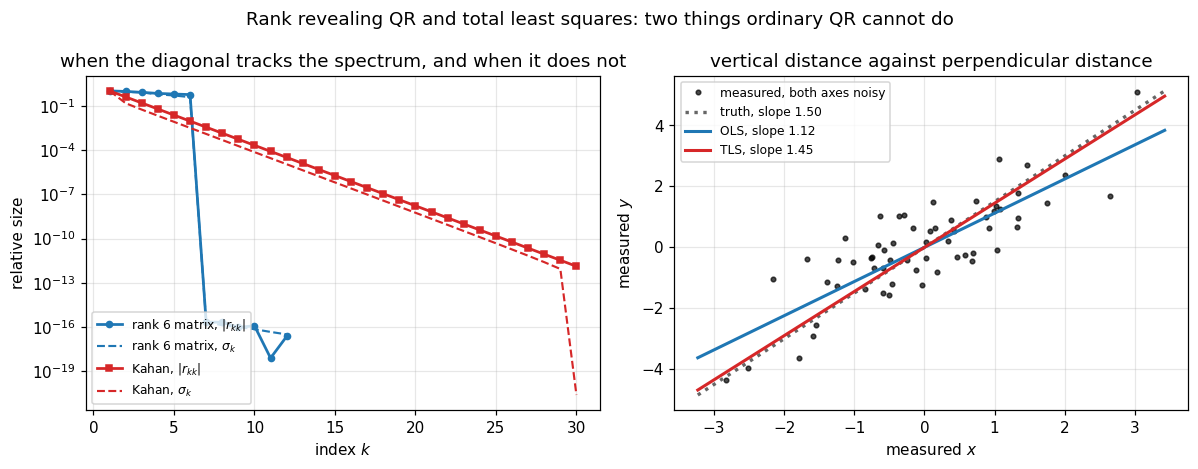

In [18]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

# left: the R diagonal against the singular values, on a good case and on Kahan
M_good = rng.standard_normal((40, 6)) @ rng.standard_normal((6, 12))
d_good = rrqr.qr_column_pivoted(M_good).diagonal
s_good = np.linalg.svd(M_good, compute_uv=False)
K_bad = rrqr.kahan_matrix(30)
d_bad = rrqr.qr_column_pivoted(K_bad).diagonal
s_bad = np.linalg.svd(K_bad, compute_uv=False)

axL.semilogy(np.arange(1, d_good.size + 1), d_good / d_good[0], "C0o-", lw=1.8, ms=4,
             label=r"rank 6 matrix, $|r_{kk}|$")
axL.semilogy(np.arange(1, s_good.size + 1), s_good / s_good[0], "C0--", lw=1.4,
             label=r"rank 6 matrix, $\sigma_k$")
axL.semilogy(np.arange(1, d_bad.size + 1), d_bad / d_bad[0], "C3s-", lw=1.8, ms=4,
             label=r"Kahan, $|r_{kk}|$")
axL.semilogy(np.arange(1, s_bad.size + 1), s_bad / s_bad[0], "C3--", lw=1.4,
             label=r"Kahan, $\sigma_k$")
axL.set_xlabel("index $k$")
axL.set_ylabel("relative size")
axL.set_title("when the diagonal tracks the spectrum, and when it does not")
axL.legend(fontsize=8, loc="lower left")

# right: the two fits, vertical distance against perpendicular distance
gen = np.random.default_rng(3)
data = rrqr.errors_in_variables(60, 1, 0.6, 0.15, gen, coefficients=[1.5])
xs = data["A"][:, 0]
ys = data["b"]
grid = np.linspace(xs.min() - 0.4, xs.max() + 0.4, 50)
slope_ols = ls.solve_qr(data["A"], ys).x[0]
slope_tls = rrqr.total_least_squares(data["A"], ys).x[0]
axR.plot(xs, ys, "k.", ms=6, alpha=0.7, label="measured, both axes noisy")
axR.plot(grid, 1.5 * grid, "0.4", lw=2.2, ls=":", label="truth, slope 1.50")
axR.plot(grid, slope_ols * grid, "C0-", lw=2, label=f"OLS, slope {slope_ols:.2f}")
axR.plot(grid, slope_tls * grid, "C3-", lw=2, label=f"TLS, slope {slope_tls:.2f}")
axR.set_xlabel("measured $x$")
axR.set_ylabel("measured $y$")
axR.set_title("vertical distance against perpendicular distance")
axR.legend(fontsize=8)

fig.suptitle("Rank revealing QR and total least squares: two things ordinary QR cannot do",
             fontsize=12)
fig.tight_layout()
plt.show()

**The left panel is the whole rank story.** On the rank 6 matrix the solid and dashed blue
curves fall together and both show the same cliff. On the Kahan matrix the red solid curve
decays smoothly and the red dashed curve dives past it: the diagonal reports a healthy matrix
and the spectrum reports a singular one.

**The right panel is the whole bias story.** The ordinary fit is visibly flatter than the truth,
and the total least squares fit is not.

---

## 10. Exercises

**Level 1, conceptual**

1.1 Why does an ordinary QR factorization tell you nothing about the numerical rank, when the
diagonal of $R$ clearly contains small numbers?

1.2 Pivoted QR found the rank correctly on every random test in this lesson and failed
completely on the Kahan matrix. Is that a bug, and what should you conclude from a pivoted QR
whose diagonal shows no gap?

1.3 Total least squares gives a better answer than ordinary least squares on noisy data, and is
worse conditioned. Explain how both can be true, and say which one decides whether you use it.

**Level 2, mathematical**

2.1 Prove that column pivoting makes the diagonal of $R$ non-increasing, and show by example
that this does **not** imply $|r_{kk}| \ge \sigma_k(A)$.

2.2 Derive the norm downdate $c_j \leftarrow c_j\sqrt{1-(r_{kj}/c_j)^2}$, identify exactly when
it loses accuracy, and explain why that is the case the algorithm cares about most.

2.3 Show that every column of the Kahan matrix has the same 2-norm, and hence that the pivot
search finds a tie at every step.

2.4 Prove that the total least squares solution is $-\mathbf{v}_{1:n}/v_{n+1}$ where
$\mathbf{v}$ is the last right singular vector of $[A\mid\mathbf{b}]$, and state precisely when
it fails to exist.

2.5 Derive the attenuation factor $s^2/(s^2+e^2)$ for a single predictor, and show that it is a
bias rather than a variance by taking the limit as the sample size grows.

**Level 3, computational**

3.1 Implement a **rank one downdate** of a pivoted QR: given $AP = QR$ and a column to delete,
produce the factorization of the reduced matrix without refactoring. Measure the saving and
compare with the row update of lesson 31.

3.2 Implement **strong rank revealing QR**, which continues to swap columns after the initial
pivoting whenever a swap would increase $|\det R_{11}|$. Show that it defeats the Kahan matrix,
and measure what it costs.

3.3 Implement **regularized total least squares**, which adds a Tikhonov penalty to the TLS
problem, and find a problem where it beats both ordinary least squares and plain TLS.

**Level 4, experimental**

4.1 Measure how the pivoted QR rank estimate degrades as a genuine rank gap narrows. Construct
matrices with a gap of $10^{k}$ for $k$ from 16 down to 1 and find where the estimate stops
being reliable, for both the QR and the SVD.

4.2 Compare greedy subset selection against exhaustive search over a range of column
correlations, and fit how the greedy penalty grows with the correlation. Then check whether
selecting on $\sigma_{\min}$ and selecting on the projection residual choose the same columns.

4.3 Measure the sensitivity of the total least squares solution to a perturbation, and fit it
against both $\kappa(A)$ and $\sigma_1/(\sigma_n(A)-\sigma_{n+1}(C))$. Confirm which one
predicts it.

**Level 5, advanced**

5.1 **Rank revealing is not one property.** There are two bounds people want,
$\sigma_k(A) \le c\,|r_{kk}|$ and $|r_{k+1,k+1}| \le c\,\sigma_{k+1}(A)$. Show they are
different, work out which one column pivoting gives, and explain which one the Kahan matrix
violates.

5.2 **The GPS problem.** Position from satellite ranges is a nonlinear least squares problem in
which the satellite positions are themselves measured. Set it up, solve it with ordinary least
squares on the linearized system, and then with total least squares, and discuss what changes.
Lesson 34 does the nonlinear part; this exercise is about the errors in variables part.

5.3 **When neither is right.** Total least squares assumes the errors in $A$ and $\mathbf{b}$
have the same variance and are uncorrelated. Derive the **scaled** total least squares problem
that drops the first assumption, implement it, and measure how wrong plain TLS is when the
variances differ by a factor of 100.

## 11. Key takeaways

- **An ordinary QR cannot reveal the rank**, because the diagonal of $R$ reports the column
  ordering as much as the matrix. Measured: shuffling the columns of a rank 3 matrix changes
  the diagonal by orders of magnitude and does not change the rank.
- **Column pivoting makes the diagonal non-increasing by construction.** Take the column with
  the longest unexplained part, every step, and the largest available is what lands on the
  diagonal.
- **The column norms are downdated, not recomputed**, which turns $O(mn^2)$ of extra work into
  $O(n^2)$, and the downdate loses accuracy exactly when a norm collapses, which is the case
  that matters. The fix is to recompute only there.
- **A rank gap is an outlier ratio, not a large ratio.** On a geometrically spaced spectrum the
  largest ratio equals the common ratio, and the correct conclusion is that there is no rank.
- **Kahan's matrix defeats pivoting completely.** Every column has the same norm, so **zero
  swaps** happen at any size, and the condition number is understated by a factor reaching
  $10^{11}$. From $n = 24$ the QR and SVD rank verdicts disagree.
- **So a gap in $R$ is evidence of rank deficiency, and no gap is not evidence of full rank.**
  The guarantee is one-sided and points the wrong way for reassurance.
- **Greedy subset selection is optimal when the choice is easy and suboptimal when it is not.**
  Measured: 60 of 60 optimal on graded columns, a handful of 60 on correlated columns with a
  median $\sigma_{\min}$ ratio around 0.90 and a worst case near 0.68.
- **Total least squares is a different problem, not a better algorithm.** It minimises the
  perpendicular distance rather than the vertical one, and it is the right problem when $A$ was
  measured.
- **Its solution is the last right singular vector of $[A\mid\mathbf{b}]$**, and the correction
  it applies has Frobenius norm exactly $\sigma_{\min}([A\mid\mathbf{b}])$, which is
  Eckart-Young in one line.
- **Ordinary least squares is biased when $A$ is noisy**, by exactly $s^2/(s^2+e^2)$, confirmed
  to three decimal places at every noise level tested. At noise equal to the signal, a slope of
  2 is estimated as 1.0.
- **The bias does not shrink with more data.** Measured from $m = 50$ to $m = 20000$: the mean
  stays at 1.60 while the standard deviation falls by a factor of 18. More data makes the
  answer **more precisely wrong**.
- **Total least squares is worse conditioned than ordinary least squares**, because its closed
  form **subtracts** $\sigma_{\min}^2$ from $A^TA$ where Tikhonov adds $\lambda^2$. Same
  expression, opposite sign, opposite effect.
- **And what governs its sensitivity is not $\kappa(A)$** but the gap between $\sigma_n(A)$ and
  $\sigma_{n+1}([A\mid\mathbf{b}])$. Measured: a matrix with $\kappa(A) = 2$ giving a TLS
  problem amplified by more than $10^{4}$.

## Where this goes next

**Lesson 34** finishes Part 5 with nonlinear least squares: Gauss-Newton, Levenberg-Marquardt,
and the GPS problem, where the model itself is nonlinear in its parameters and the linear
theory of the last five lessons is applied one step at a time.

**Lesson 41** builds the SVD properly, including the Eckart-Young theorem this lesson used on
credit, and lesson 43 develops low rank approximation, of which total least squares is the
smallest interesting case.

**Lesson 42** shows how the SVD is actually computed, starting from the Golub-Kahan
bidiagonalization that appeared in lesson 32's exercises.

Solutions are in [`solutions/part05_least_squares_and_qr.md`](../solutions/part05_least_squares_and_qr.md).